In [19]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [20]:
# 2. DATA LOADING & INSPECTION
df = pd.read_csv('precious_metals_historical_data.csv')

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

print("Data Shape")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("Data Info (Types & Nulls)")
print(df.info())
print("\n")

print("Basic Statistics")
display(df.describe())

Data Shape
Rows: 2513, Columns: 15

Data Info (Types & Nulls)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2513 entries, 0 to 2512
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     2513 non-null   datetime64[ns]
 1   Silver_Price             2513 non-null   float64       
 2   Gold_Price               2513 non-null   float64       
 3   Platinum_Price           2513 non-null   float64       
 4   Silver_Returns           2512 non-null   float64       
 5   Gold_Returns             2512 non-null   float64       
 6   Platinum_Returns         2512 non-null   float64       
 7   Gold_Silver_Ratio        2513 non-null   float64       
 8   Silver_Volatility_30d    2483 non-null   float64       
 9   Gold_Volatility_30d      2483 non-null   float64       
 10  Platinum_Volatility_30d  2483 non-null   float64       
 11  Silver_MA50              2464 non

,Date,Silver_Price,Gold_Price,Platinum_Price,Silver_Returns,Gold_Returns,Platinum_Returns,Gold_Silver_Ratio,Silver_Volatility_30d,Gold_Volatility_30d,Platinum_Volatility_30d,Silver_MA50,Silver_MA200,Gold_MA50,Gold_MA200
count,2513,2513.000000,2513.000000,2513.000000,2512.000000,2512.000000,2512.000000,2513.000000,2483.000000,2483.000000,2483.000000,2464.000000,2314.000000,2464.000000,2314.000000
mean,2021-01-29 04:14:59.641862144,21.429594,173.897517,93.073480,0.000905,0.000622,0.000507,8.198247,0.256662,0.139474,0.251259,20.951098,20.345685,171.956878,167.662906
min,2016-02-03 00:00:00,11.210000,107.339996,55.360001,-0.150233,-0.064269,-0.136599,4.683333,0.110760,0.064632,0.113060,13.555400,13.986600,112.089000,117.232300
25%,2018-08-01 00:00:00,15.910000,123.650002,84.290001,-0.007996,-0.004460,-0.009420,7.615631,0.184876,0.105537,0.193499,15.873400,15.876362,123.435200,122.604363
50%,2021-01-29 00:00:00,19.840000,165.089996,89.370003,0.000716,0.000720,0.000439,8.183206,0.237276,0.132642,0.237388,20.423000,19.850100,166.349700,167.898750
75%,2023-07-31 00:00:00,23.590000,183.490005,95.290001,0.009338,0.005523,0.009601,8.704824,0.294129,0.159719,0.288626,23.363850,23.002225,181.124950,178.831288
max,2026-01-30 00:00:00,105.599998,495.899994,252.250000,0.091429,0.049038,0.110372,12.551293,0.816880,0.357717,0.875470,67.071398,43.942449,410.146801,347.524950
std,NaN,9.145891,64.561248,18.822152,0.018044,0.009496,0.017444,0.921010,0.106426,0.048793,0.097596,7.030559,5.264943,59.499504,49.364931


Missing Value Check


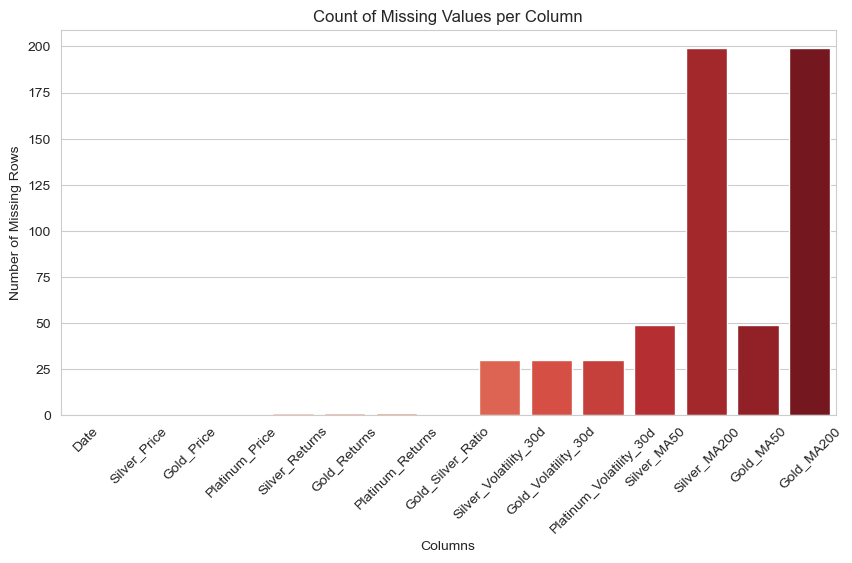

In [21]:
# 3. DATA CLEANING (Missing Values)
print("Missing Value Check")

# Calculate the actual number of missing values per column
missing_counts = df.isnull().sum()

if missing_counts.sum() == 0:
    print("Great news, No missing values found in the dataset.")
    print("The dataset is clean, so no plot is needed here.")
else:
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=missing_counts.index, 
        y=missing_counts.values, 
        hue=missing_counts.index,  
        legend=False,              
        palette='Reds'
    )
    plt.title("Count of Missing Values per Column")
    plt.ylabel("Number of Missing Rows")
    plt.xlabel("Columns")
    plt.xticks(rotation=45) 
    plt.show()

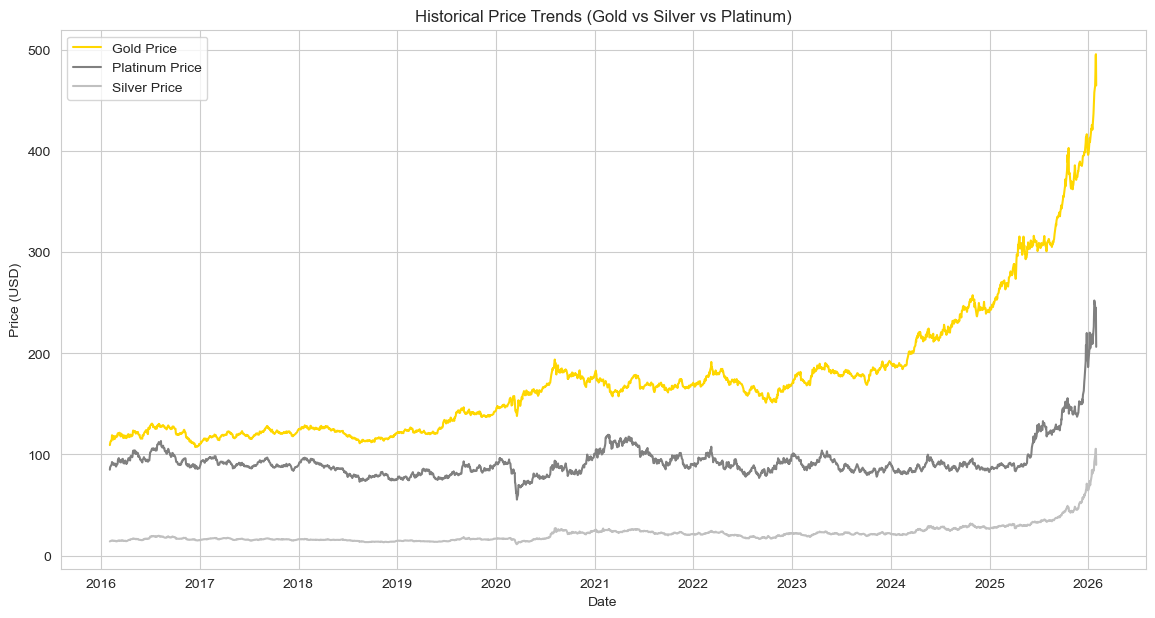

In [22]:
# 4. IDENTIFY TRENDS (Time Series Analysis)
# Plotting Gold, Silver, and Platinum Prices over time
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Gold_Price'], label='Gold Price', color='gold')
plt.plot(df['Date'], df['Platinum_Price'], label='Platinum Price', color='gray')
plt.plot(df['Date'], df['Silver_Price'], label='Silver Price', color='silver')
plt.title('Historical Price Trends (Gold vs Silver vs Platinum)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


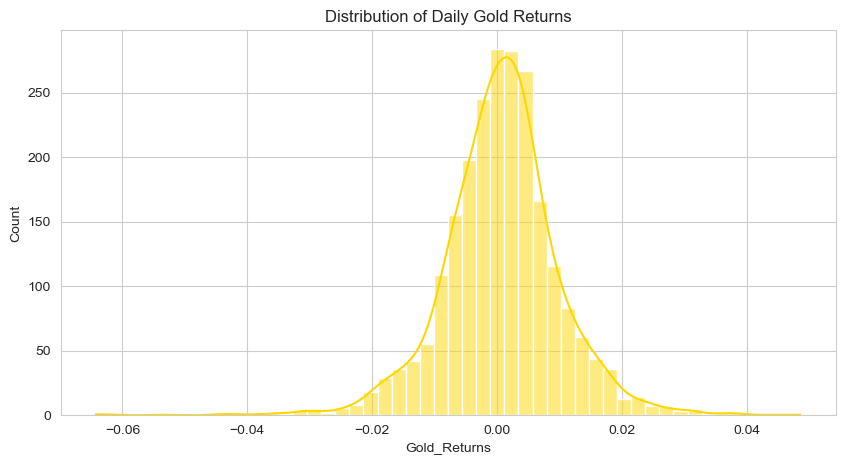

In [23]:
# 5. DISTRIBUTION ANALYSIS (Histograms)
# Check the distribution of Gold Returns
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Gold_Returns'], bins=50, kde=True, color='gold')
plt.title('Distribution of Daily Gold Returns')
plt.show()

Correlation Analysis


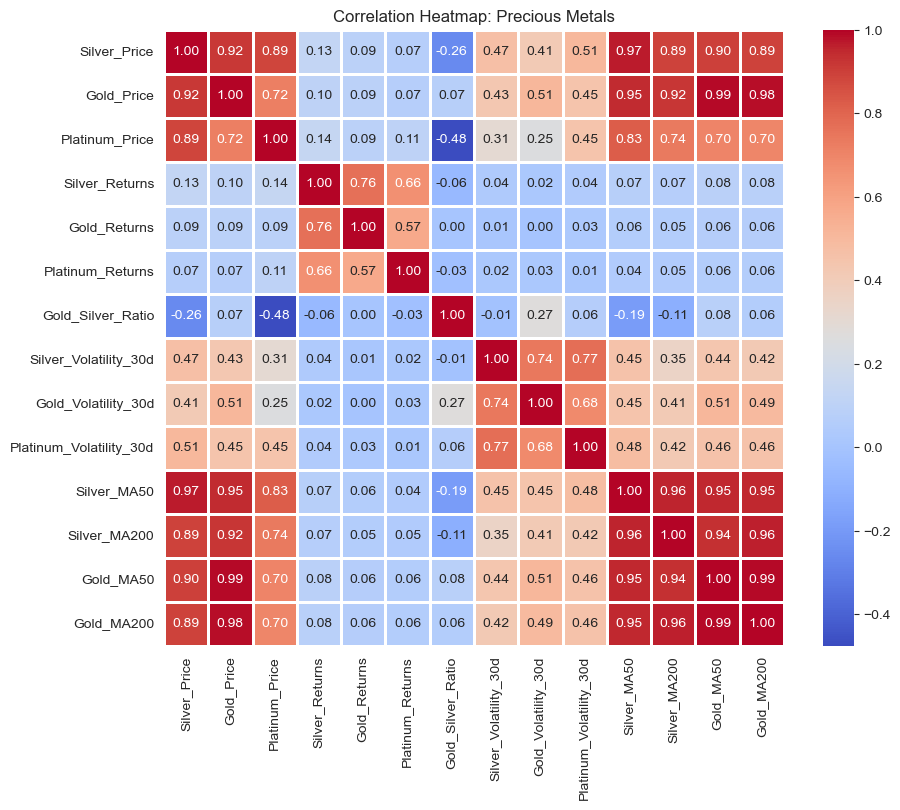

In [26]:
# 6. DISCOVER RELATIONSHIPS (Correlation)
# Correlation Matrix Heatmap
print("Correlation Analysis")

#Filter for numeric columns only
numeric_df = df_clean.select_dtypes(include=[np.number])

#Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = numeric_df.corr()

sns.heatmap(
    correlation_matrix, 
    annot=True,         # Show numbers
    cmap='coolwarm',    # Blue (Low) to Red (High)
    fmt=".2f", 
    linewidths=1, 
    linecolor='white'
)
plt.title('Correlation Heatmap: Precious Metals')
plt.show()

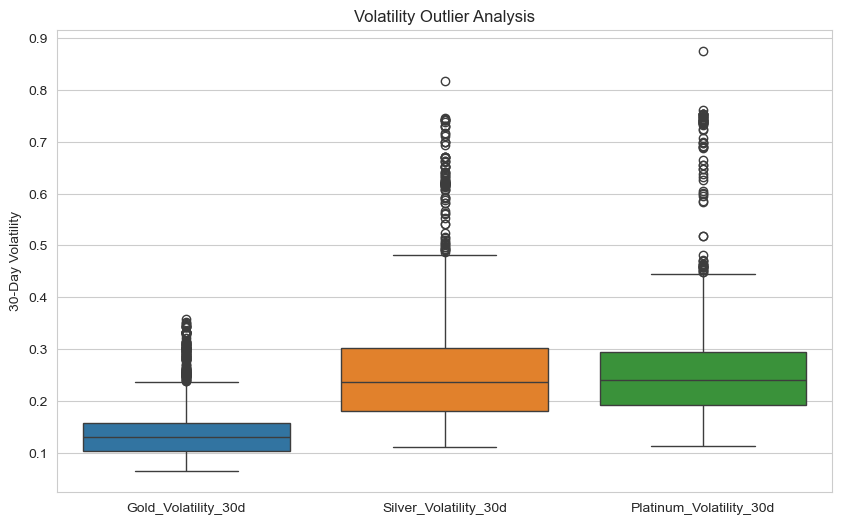

In [ ]:
# 7. OUTLIER DETECTION (Boxplots)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean[['Gold_Volatility_30d', 'Silver_Volatility_30d', 'Platinum_Volatility_30d']])
plt.title('Volatility Outlier Analysis')
plt.ylabel('30-Day Volatility')
plt.show()